In [1]:
!date

Sun Sep  6 14:30:26 PDT 2026


In [2]:
import pandas as pd
import numpy as np
from scipy.stats import pearsonr
import matplotlib.pyplot as plt

projdir = '/u/project/cluo/terencew/claude/project_ideas/pool_design'

In [3]:
### load per-droplet scores and tag each pool with its design metric (min_dist)
scored = pd.read_csv(f'{projdir}/csv/ambisim/droplet_scores.csv', sep='\t')

design = pd.read_csv(f'{projdir}/csv/designs/nominated_pools_n8.tsv', sep='\t')
design['pool'] = design['universe'] + '__' + design['strategy'] + '__rep' + design['rep'].astype(str)
design = design.drop_duplicates('pool')[['pool', 'min_dist', 'kl_min']]

scored = scored.merge(design, on='pool', how='left')
scored.head()

,pool,universe,strategy,rep,modality,barcode,is_true_singlet,called_singlet,correct,ambient_frac,ll_gap,called_donor,true_donor,min_dist,kl_min
0,AFR_only__greedy_maxmin__rep1,AFR_only,greedy_maxmin,1,gex,AAACAGCCAAACAACA,True,True,True,0.098320,13.41,NA20334,NA20334,113.7717,2.23535
1,AFR_only__greedy_maxmin__rep1,AFR_only,greedy_maxmin,1,gex,AAACAGCCAAACATAG,True,True,True,0.156914,15.59,NA19042,NA19042,113.7717,2.23535
2,AFR_only__greedy_maxmin__rep1,AFR_only,greedy_maxmin,1,gex,AAACAGCCAAACCCTA,True,True,True,0.391450,0.05,HG03081,HG03081,113.7717,2.23535
3,AFR_only__greedy_maxmin__rep1,AFR_only,greedy_maxmin,1,gex,AAACAGCCAAACCTAT,True,False,False,0.314493,0.00,HG02678,HG02678,113.7717,2.23535
4,AFR_only__greedy_maxmin__rep1,AFR_only,greedy_maxmin,1,gex,AAACAGCCAAACCTTG,True,True,True,0.184638,30.66,NA19707,NA19707,113.7717,2.23535


In [4]:
### NOTE: adversarial_mindist/adversarial_family pools (the intended worst-case
### floor) haven't finished demuxlet yet -- of the 32 pools ready here, all are
### rep1 of the core grid (random / greedy_maxmin / greedy_maxmean / greedy_maxkl /
### ancestry_balanced). So "tier" below splits the best-available design range
### into thirds by min_dist, not a true optimistic-vs-pessimistic floor comparison.
pool_dist = scored.drop_duplicates('pool')[['pool', 'min_dist']]
edges = pool_dist['min_dist'].quantile([1/3, 2/3]).values
pool_dist['tier'] = pd.cut(pool_dist['min_dist'], bins=[-np.inf, edges[0], edges[1], np.inf],
                           labels=['low_dist', 'mid_dist', 'high_dist'])
scored = scored.merge(pool_dist[['pool', 'tier']], on='pool', how='left')
pool_dist['tier'].value_counts()

low_dist     11
high_dist    11
mid_dist     10
Name: tier, dtype: int64

In [5]:
### restrict to true singlets, bin by ambient RNA %. Accuracy is computed over
### ALL true singlets (a wrong demuxlet doublet/ambiguous call counts against it);
### LL-gap is only defined where demuxlet actually called a singlet, so that
### subset (sng_called) is used only for the margin metrics, not accuracy.
sng_true = scored[scored['is_true_singlet']].copy()
sng_true['ambient_bin'] = pd.cut(sng_true['ambient_frac'], bins=[0, 0.1, 0.2, 0.3, 0.4, 1.0],
                                  labels=['0-10%', '10-20%', '20-30%', '30-40%', '40%+'])
sng_called = sng_true[sng_true['called_singlet']]
sng_true.groupby('ambient_bin').size()

ambient_bin
0-10%     117088
10-20%    175424
20-30%    124480
30-40%     65600
40%+       35744
dtype: int64

In [6]:
### accuracy + LL-gap by ambient bin x design tier x modality -- directly answers
### "in what ambient regimes does pool design actually matter?"
acc_strat = sng_true.groupby(['modality', 'ambient_bin', 'tier'], observed=True).agg(
    accuracy=('correct', 'mean'), n_true_singlets=('correct', 'size')).reset_index()

gap_strat = sng_called.groupby(['modality', 'ambient_bin', 'tier'], observed=True).agg(
    ll_gap_median=('ll_gap', 'median'),
    ll_gap_p5=('ll_gap', lambda x: np.percentile(x, 5)),
    n_called_singlets=('ll_gap', 'size'),
).reset_index()

strat = acc_strat.merge(gap_strat, on=['modality', 'ambient_bin', 'tier'])
strat

,modality,ambient_bin,tier,accuracy,n_true_singlets,ll_gap_median,ll_gap_p5,n_called_singlets
0,atac,0-10%,low_dist,0.999499,19976,29.920,6.7700,19966
1,atac,0-10%,mid_dist,0.999559,18160,30.470,6.9455,18152
2,atac,0-10%,high_dist,0.999299,19976,32.310,7.6100,19962
3,atac,10-20%,low_dist,0.994297,30162,22.960,3.8000,29990
4,atac,10-20%,mid_dist,0.994092,27420,23.580,3.9700,27258
5,atac,10-20%,high_dist,0.995988,30162,24.985,4.3700,30042
6,atac,20-30%,low_dist,0.958877,21472,14.680,0.6840,20589
7,atac,20-30%,mid_dist,0.957736,19520,15.070,0.7670,18695
8,atac,20-30%,high_dist,0.958411,21472,15.770,1.0100,20580
9,atac,30-40%,low_dist,0.795216,11539,7.730,-0.8600,9176


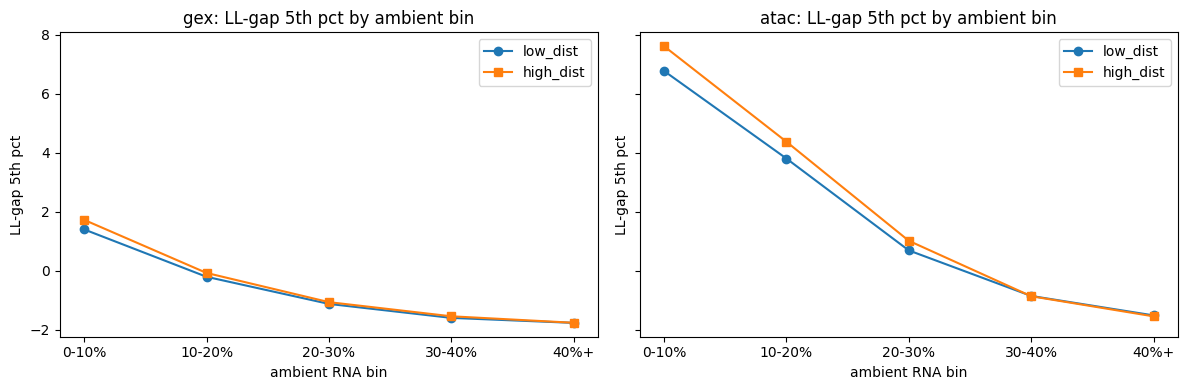

In [7]:
### plot: does the low-dist vs high-dist LL-gap gap widen as ambient RNA increases?
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, modality in zip(axes, ['gex', 'atac']):
    for tier, marker in zip(['low_dist', 'high_dist'], ['o', 's']):
        sub = strat[(strat['modality'] == modality) & (strat['tier'] == tier)]
        ax.plot(sub['ambient_bin'].astype(str), sub['ll_gap_p5'], marker=marker, label=tier)
    ax.set_title(f'{modality}: LL-gap 5th pct by ambient bin')
    ax.set_xlabel('ambient RNA bin'); ax.set_ylabel('LL-gap 5th pct')
    ax.legend()
plt.tight_layout()
plt.show()

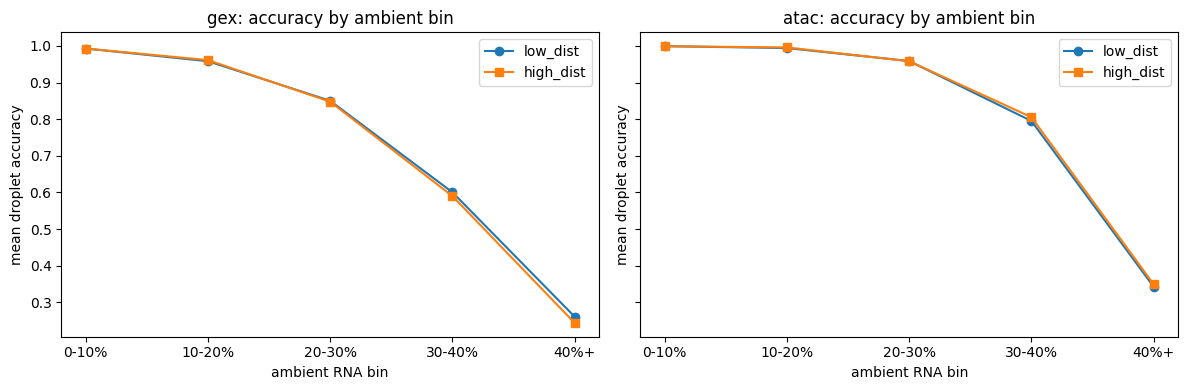

In [8]:
### same view for accuracy
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, modality in zip(axes, ['gex', 'atac']):
    for tier, marker in zip(['low_dist', 'high_dist'], ['o', 's']):
        sub = strat[(strat['modality'] == modality) & (strat['tier'] == tier)]
        ax.plot(sub['ambient_bin'].astype(str), sub['accuracy'], marker=marker, label=tier)
    ax.set_title(f'{modality}: accuracy by ambient bin')
    ax.set_xlabel('ambient RNA bin'); ax.set_ylabel('mean droplet accuracy')
    ax.legend()
plt.tight_layout()
plt.show()

In [9]:
### continuous check: does min_dist correlate more strongly with LL-gap in
### high-ambient droplets than low-ambient droplets? (per modality)
for modality in ['gex', 'atac']:
    for label, mask in [('low ambient (<10%)', sng_called['ambient_frac'] < 0.1),
                         ('high ambient (>=30%)', sng_called['ambient_frac'] >= 0.3)]:
        sub = sng_called[(sng_called['modality'] == modality) & mask]
        pool_level = sub.groupby('pool').agg(ll_gap_p5=('ll_gap', lambda x: np.percentile(x, 5)),
                                              min_dist=('min_dist', 'first')).dropna()
        r, p = pearsonr(pool_level['min_dist'], pool_level['ll_gap_p5'])
        print(f'{modality:5s} {label:22s} min_dist vs LL-gap p5: r={r:+.3f} p={p:.3f} (n_pools={len(pool_level)})')

gex   low ambient (<10%)     min_dist vs LL-gap p5: r=+0.484 p=0.005 (n_pools=32)
gex   high ambient (>=30%)   min_dist vs LL-gap p5: r=+0.169 p=0.356 (n_pools=32)
atac  low ambient (<10%)     min_dist vs LL-gap p5: r=+0.529 p=0.002 (n_pools=32)
atac  high ambient (>=30%)   min_dist vs LL-gap p5: r=+0.069 p=0.707 (n_pools=32)


In [10]:
### does accuracy vs. min_dist recover a signal once split by ambient bin, rather
### than pooled across all ambient levels? the pooled GEX accuracy correlation
### (01b) was r=0.06, n.s. -- if that's an average over a low-ambient regime where
### a real effect exists and a high-ambient regime where it's swamped by noise
### (the same pattern already seen for LL-gap above), splitting should recover it.
for modality in ['gex', 'atac']:
    print(f'--- {modality}: accuracy vs min_dist, by ambient bin ---')
    sub_mod = sng_true[sng_true['modality'] == modality]
    for b in ['0-10%', '10-20%', '20-30%', '30-40%', '40%+']:
        binned = sub_mod[sub_mod['ambient_bin'] == b]
        pool_acc = binned.groupby('pool').agg(acc=('correct', 'mean'), n=('correct', 'size'),
                                               min_dist=('min_dist', 'first'))
        pool_acc = pool_acc[pool_acc['n'] >= 20]
        r, p = pearsonr(pool_acc['min_dist'], pool_acc['acc'])
        print(f'  {b:8s}: r={r:+.3f} p={p:.3f}  n_pools={len(pool_acc)}  mean_acc={pool_acc["acc"].mean():.3f}')

--- gex: accuracy vs min_dist, by ambient bin ---
  0-10%   : r=+0.096 p=0.603  n_pools=32  mean_acc=0.993
  10-20%  : r=+0.365 p=0.040  n_pools=32  mean_acc=0.958


  20-30%  : r=+0.128 p=0.486  n_pools=32  mean_acc=0.843
  30-40%  : r=-0.092 p=0.618  n_pools=32  mean_acc=0.590
  40%+    : r=-0.172 p=0.345  n_pools=32  mean_acc=0.251
--- atac: accuracy vs min_dist, by ambient bin ---
  0-10%   : r=+0.023 p=0.902  n_pools=32  mean_acc=0.999
  10-20%  : r=+0.593 p=0.000  n_pools=32  mean_acc=0.995
  20-30%  : r=+0.181 p=0.322  n_pools=32  mean_acc=0.958


  30-40%  : r=+0.443 p=0.011  n_pools=32  mean_acc=0.800
  40%+    : r=+0.220 p=0.226  n_pools=32  mean_acc=0.344


In [11]:
### verdict: doesn't cleanly rescue the pooled null. ATAC recovers a real signal
### in some (not all) non-ceiling bins (10-20%: r=0.593 p<0.001; 30-40%: r=0.443
### p=0.011) -- consistent with the pooled r=0.435 not being pure noise. GEX does
### not: only one bin reaches marginal significance (10-20%: r=0.365 p=0.04, would
### not survive correction for the 5 bins x 2 modalities tested here), and the
### higher-ambient bins go slightly negative rather than positive. So this
### sharpens the GEX/ATAC split rather than resolving it: GEX accuracy looks
### close to null against pool design across the whole ambient range, not just
### at the ceiling, while ATAC (far more informative SNPs/reads per cell -- see
### its ~3x larger raw LL-gaps in 01b) does carry a real, if ambient-band-
### dependent, accuracy signal.

In [12]:
### write out
outdir = f'{projdir}/csv/ambisim'
strat.to_csv(f'{outdir}/droplet_ambient_stratified.csv', sep='\t', index=False)

In [13]:
!date

Sun Sep  6 14:30:31 PDT 2026
